# Lecture 4: Edges, Corners, and Blobs — Study Guide

This notebook follows the same style as Lec_3: **theory in markdown, code in cells, run it yourself and watch the outputs**.

Topics covered:
1. Edge detection basics (why edges, origin of edges)
2. Derivative filters (finite difference, Prewitt, Sobel)
3. Image gradient (magnitude & direction)
4. Noise problem + Gaussian smoothing + Derivative of Gaussian
5. Canny edge detector (full pipeline: NMS + hysteresis)
6. Harris corner detector (second moment matrix, R function)
7. Blob detection (Laplacian of Gaussian, scale selection, DoG approximation)
8. SIFT overview (detection vs description, orientation assignment)

> Note: you pushed back before on accepting explanations uncritically — good habit to keep here too. Where the math has a subtlety (e.g. why σ² normalization, why R uses trace not eigenvalues directly), I'll flag it instead of hiding it.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

## 1. What is an edge?

**Definition**: a place of *rapid change* in the image intensity function. If you take one row of pixels (a horizontal scanline) and plot intensity vs. position, an edge shows up as a steep slope in that 1D signal.

**Why edges matter**: most of the *semantic and shape* information in an image can be encoded by its edges — far more compact than the raw pixel grid. An artist's line drawing is the "ideal" edge map, but the artist also uses object-level knowledge that a plain derivative filter doesn't have.

**Origin of edges** — an edge is not one physical phenomenon, it's a symptom of several different causes:
- depth discontinuity (foreground/background boundary)
- surface color/reflectance discontinuity (e.g. printed text vs. blank paper)
- illumination discontinuity (shadow boundary)
- surface normal discontinuity (an object folds/bends)

This matters because an edge detector can't tell you *which* of these caused the edge — it only tells you intensity changed sharply.

## 2. Derivatives via convolution

The partial derivative of a continuous function is:

$$\frac{\partial f}{\partial x} = \lim_{\varepsilon \to 0} \frac{f(x+\varepsilon, y) - f(x,y)}{\varepsilon}$$

For **discrete** images we can't take the limit, so we set $\varepsilon = 1$ (the smallest possible step) and use a **finite difference approximation**:

$$\frac{\partial f}{\partial x} \approx f(x+1, y) - f(x, y) \quad \text{(forward difference)}$$

This is implementable as convolution with the kernel `[-1, 1]` (or `[1, -1]` depending on sign convention). Because it's not symmetric around the pixel of interest, a more common choice is the **central difference**:

$$\frac{\partial f}{\partial x} \approx \frac{f(x+1,y) - f(x-1,y)}{2} \quad \Rightarrow \quad \text{kernel } [-1,\ 0,\ 1]$$

**Prewitt** and **Sobel** kernels extend this central-difference idea by also averaging along the perpendicular direction (a small amount of smoothing baked into the derivative kernel — Sobel weights the center row/column more, which is why it's slightly more robust to noise than Prewitt).

**Key fact to remember** (this is a common exam-style question): 
- Smoothing filter coefficients sum to **1** → constant regions are unaffected.
- Derivative filter coefficients sum to **0** → zero response in constant (flat) regions.

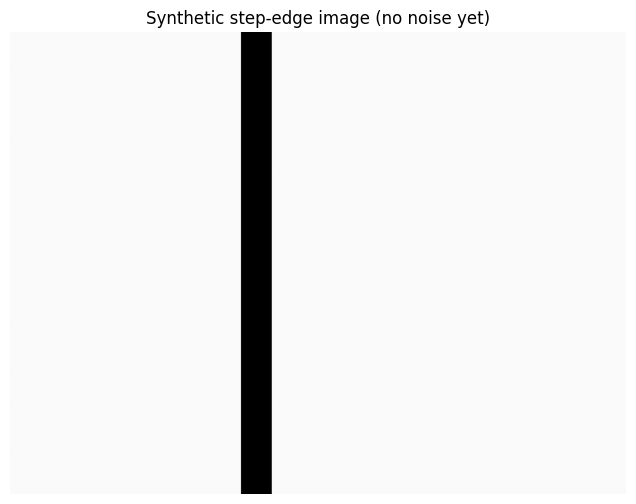

In [2]:
# Build a synthetic step-edge image (like the lecturer's example): bright background, dark stripe
img = np.ones((300, 400), dtype=np.float64) * 250
img[:, 150:170] = 0  # dark vertical stripe -> two vertical edges

plt.imshow(img, vmin=0, vmax=255)
plt.title('Synthetic step-edge image (no noise yet)')
plt.axis('off')
plt.show()

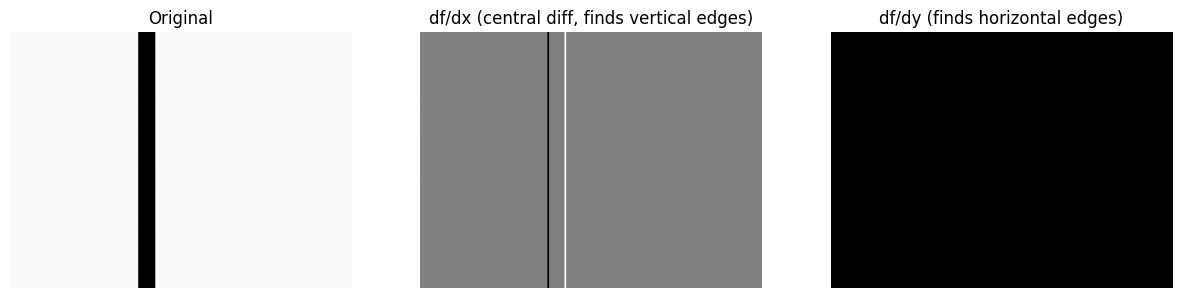

Notice im_dy is ~all zero: there are no horizontal edges in this image.


In [3]:
# Central difference kernel: [-1, 0, 1]  -> detects vertical edges (horizontal gradient, d/dx in image-x = columns)
kernel_x = np.array([[-1, 0, 1]], dtype=np.float64)   # 1x3 -> horizontal direction
kernel_y = kernel_x.T                                  # 3x1 -> vertical direction

im_dx = cv2.filter2D(img, cv2.CV_64F, kernel_x)
im_dy = cv2.filter2D(img, cv2.CV_64F, kernel_y)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, vmin=0, vmax=255); ax[0].set_title('Original')
ax[1].imshow(im_dx, cmap='gray'); ax[1].set_title('df/dx (central diff, finds vertical edges)')
ax[2].imshow(im_dy, cmap='gray'); ax[2].set_title('df/dy (finds horizontal edges)')
for a in ax: a.axis('off')
plt.show()

print('Notice im_dy is ~all zero: there are no horizontal edges in this image.')

**Exercise 1**: Modify the synthetic image above to add a *horizontal* stripe as well, then re-run the central difference filters. Confirm `im_dy` now shows a nonzero response.

**Exercise 2**: Replace `kernel_x`/`kernel_y` with the Prewitt kernels below and compare the output visually against the central-difference result. Prewitt should look slightly smoother.

```python
prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
```

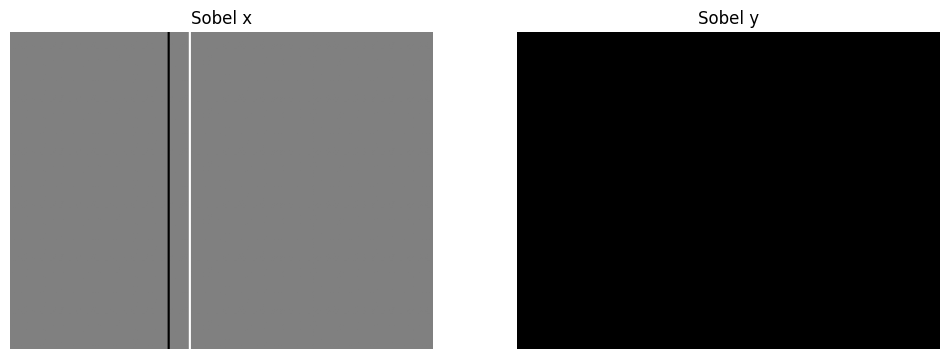

sobel_x sums to: 0.0 | sobel_y sums to: 0.0


In [4]:
# Sobel kernels — central difference PLUS a [1,2,1] smoothing pass in the perpendicular direction
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)

im_sobel_x = cv2.filter2D(img, cv2.CV_64F, sobel_x)
im_sobel_y = cv2.filter2D(img, cv2.CV_64F, sobel_y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(im_sobel_x, cmap='gray'); ax[0].set_title('Sobel x')
ax[1].imshow(im_sobel_y, cmap='gray'); ax[1].set_title('Sobel y')
for a in ax: a.axis('off')
plt.show()

# sanity check the "sum to zero" rule for derivative kernels
print('sobel_x sums to:', sobel_x.sum(), '| sobel_y sums to:', sobel_y.sum())

## 3. Image gradient: magnitude and direction

The image gradient is a **2D vector**:

$$\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$$

- **Magnitude** (edge strength): $\|\nabla f\| = \sqrt{f_x^2 + f_y^2}$
- **Direction**: $\theta = \tan^{-1}(f_y / f_x)$
- The gradient points in the direction of **steepest ascent** in intensity. The direction *of the edge itself* is **perpendicular** to the gradient direction. This fact is exactly what non-maximum suppression in Canny relies on later.

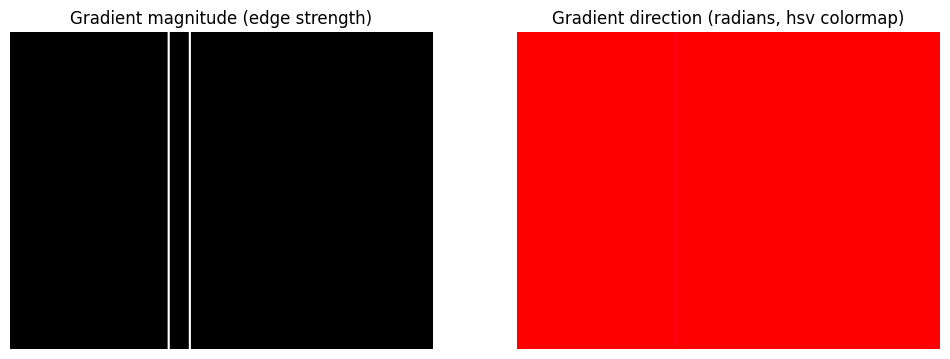

In [5]:
gradient_mag = np.sqrt(im_sobel_x**2 + im_sobel_y**2)
gradient_dir = np.arctan2(im_sobel_y, im_sobel_x)  # radians, range (-pi, pi]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(gradient_mag, cmap='gray'); ax[0].set_title('Gradient magnitude (edge strength)')
ax[1].imshow(gradient_dir, cmap='hsv'); ax[1].set_title('Gradient direction (radians, hsv colormap)')
for a in ax: a.axis('off')
plt.show()

## 4. The noise problem — and why we smooth first

Raw derivative filters are essentially **high-pass, noise-amplifying** operators: a tiny per-pixel fluctuation becomes a large spike after differentiation, because differencing consecutive noisy samples doesn't cancel — it can amplify local variance.

**Fix**: smooth (with a Gaussian) *before* differentiating.

**Derivative theorem of convolution** (the key trick that makes this efficient):

$$\frac{d}{dx}(f * g) = f * \frac{d}{dx}g$$

Since differentiation and convolution are both linear, and convolution is associative, you get the *exact same result* whether you (a) smooth the image then differentiate it, or (b) precompute the derivative-of-Gaussian kernel once and convolve the image with that single combined kernel. Option (b) is more efficient — one convolution instead of two.

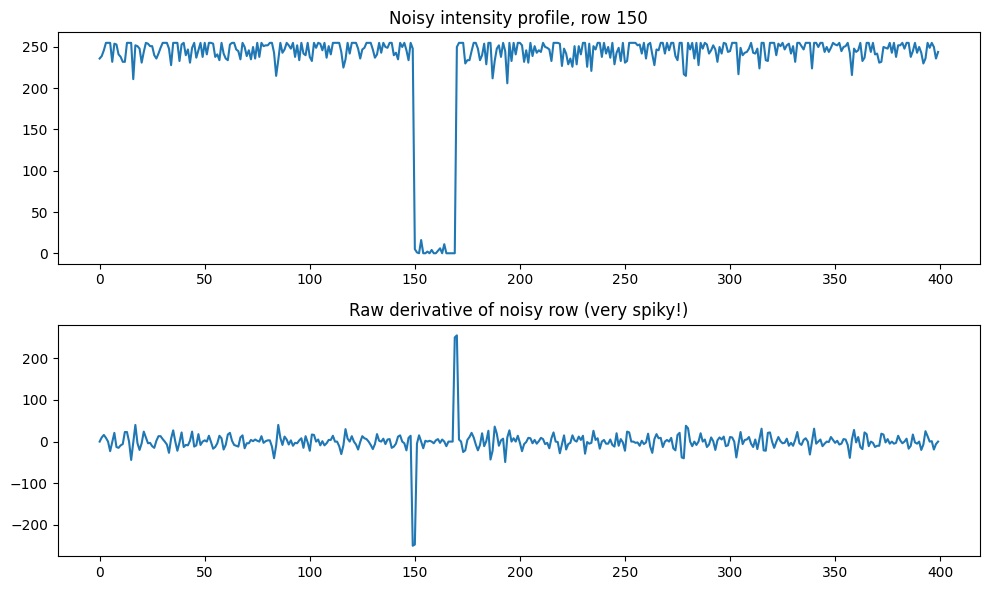

In [6]:
# Reproduce the lecturer's noisy-edge demo
np.random.seed(0)
img_u8 = np.ones((300, 400), dtype=np.uint8) * 250
img_u8[:, 150:170] = 0

img_norm = img_u8.astype(np.float64) / 255.0
noise = np.random.normal(0, 0.05, img_norm.shape)
noisy = cv2.add(img_norm, noise)
noisy = np.clip(noisy, 0, 1)
noisy_u8 = (noisy * 255).astype(np.uint8)

row = 150
kernel_center_diff = np.array([[-1, 0, 1]], dtype=np.float64)
f_x_noisy = cv2.filter2D(noisy_u8.astype(np.float64), cv2.CV_64F, kernel_center_diff)

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(noisy_u8[row, :]); ax[0].set_title(f'Noisy intensity profile, row {row}')
ax[1].plot(f_x_noisy[row, :]); ax[1].set_title('Raw derivative of noisy row (very spiky!)')
plt.tight_layout(); plt.show()

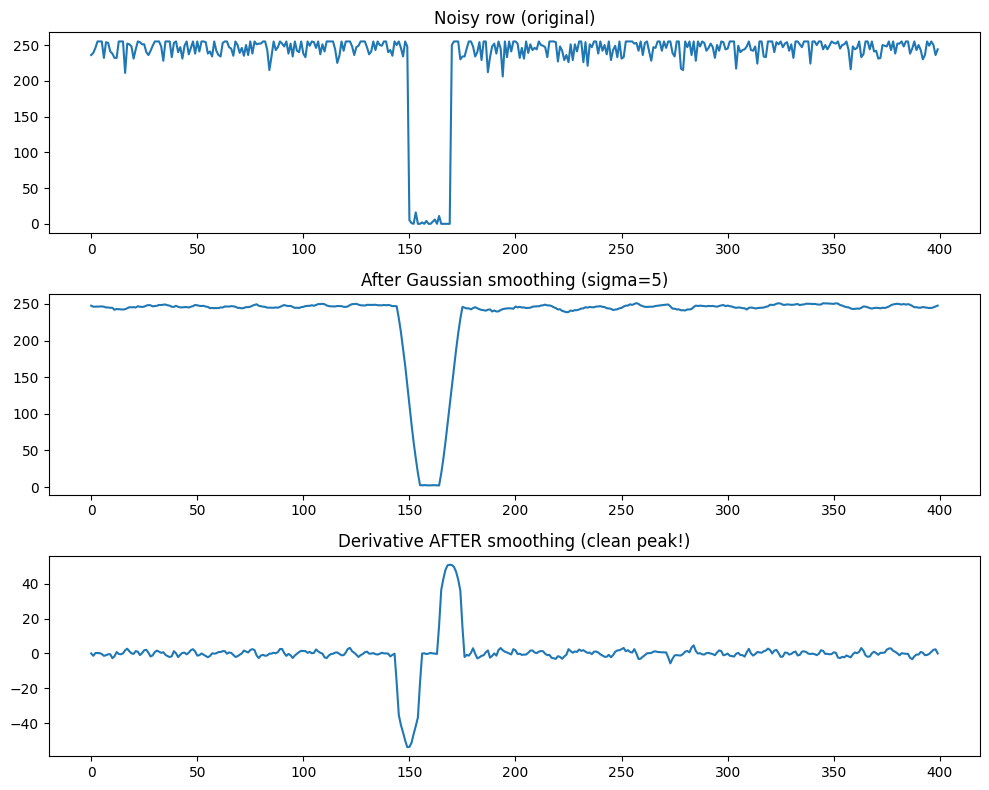

In [7]:
# Now smooth first with a Gaussian, then differentiate
def gaussian_kernel_1d(ksize=11, sigma=5):
    k = cv2.getGaussianKernel(ksize, sigma)
    return k  # column vector, shape (ksize,1)

g1d = gaussian_kernel_1d(11, 5)
smoothed = cv2.filter2D(noisy_u8.astype(np.float64), cv2.CV_64F, g1d.T)  # smooth along rows
f_x_smooth = cv2.filter2D(smoothed, cv2.CV_64F, kernel_center_diff)

fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(noisy_u8[row, :]); ax[0].set_title('Noisy row (original)')
ax[1].plot(smoothed[row, :]); ax[1].set_title('After Gaussian smoothing (sigma=5)')
ax[2].plot(f_x_smooth[row, :]); ax[2].set_title('Derivative AFTER smoothing (clean peak!)')
plt.tight_layout(); plt.show()

**Exercise 3 (homework from the lecture)**: Instead of smoothing then differentiating in two passes, build a single **derivative-of-Gaussian** kernel and convolve the noisy row with it directly. You should get (numerically) the same result as the two-step version above. Try:

```python
dog_kernel = cv2.filter2D(g1d, cv2.CV_64F, kernel_center_diff.T)  # derivative of the gaussian kernel itself
f_x_direct = cv2.filter2D(noisy_u8.astype(np.float64), cv2.CV_64F, dog_kernel.T)
```
Compare `f_x_direct[row,:]` to `f_x_smooth[row,:]` — they should match closely (up to boundary/padding effects).

## 5. Scale of the Gaussian derivative filter

Larger $\sigma$ (kernel "width") → more smoothing → less noise, but also **more blur** on the edge itself, and the filter starts responding to features at a coarser **scale**. There's a trade-off: small $\sigma$ keeps edges sharp but is noise-sensitive; large $\sigma$ is robust to noise but blurs and can even merge nearby edges. This "scale" concept comes back later in blob detection — it's not a one-off idea specific to edges.

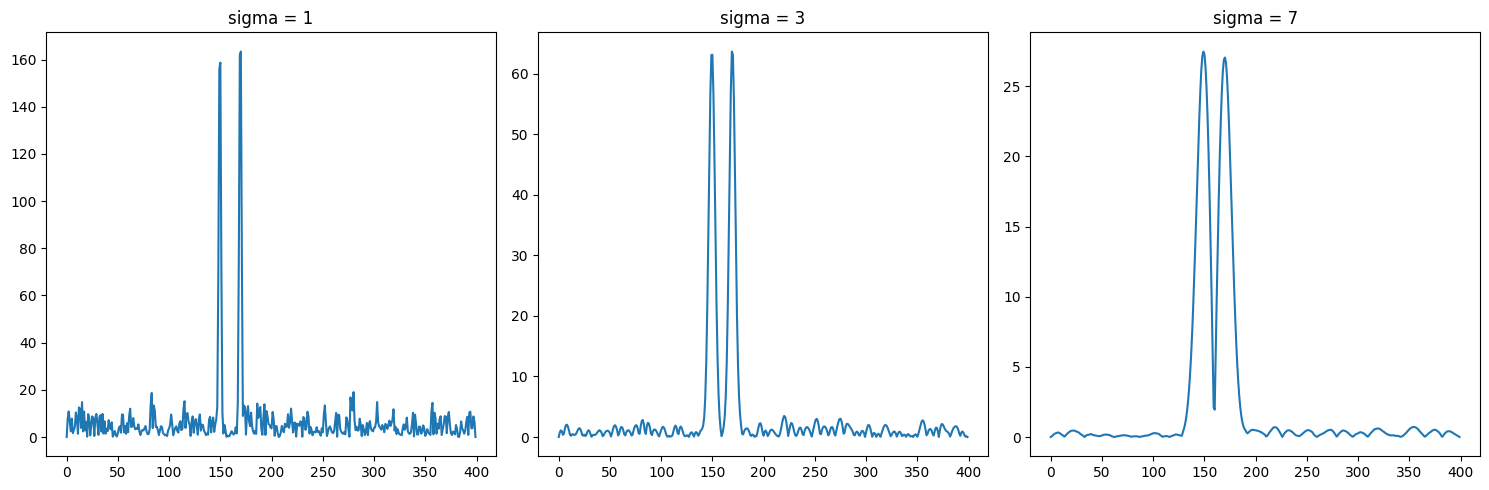

Notice: bigger sigma -> wider, smoother peak (coarser scale), smaller sigma -> sharp but noisier.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, sigma in zip(axes, [1, 3, 7]):
    ksize = int(6*sigma+1) | 1  # ensure odd
    g = cv2.getGaussianKernel(ksize, sigma)
    smoothed_s = cv2.filter2D(noisy_u8.astype(np.float64), cv2.CV_64F, g.T)
    deriv_s = cv2.filter2D(smoothed_s, cv2.CV_64F, kernel_center_diff)
    ax.plot(np.abs(deriv_s[row, :]))
    ax.set_title(f'sigma = {sigma}')
plt.tight_layout(); plt.show()
print('Notice: bigger sigma -> wider, smoother peak (coarser scale), smaller sigma -> sharp but noisier.')

## 6. 2D Derivative-of-Gaussian filters (visualizing the kernels themselves)

This reproduces the meshgrid demo from lecture: build a 2D Gaussian on a grid, then apply the central-difference kernel to *the Gaussian itself* (not an image) to visualize the x- and y-derivative-of-Gaussian kernels as surfaces.

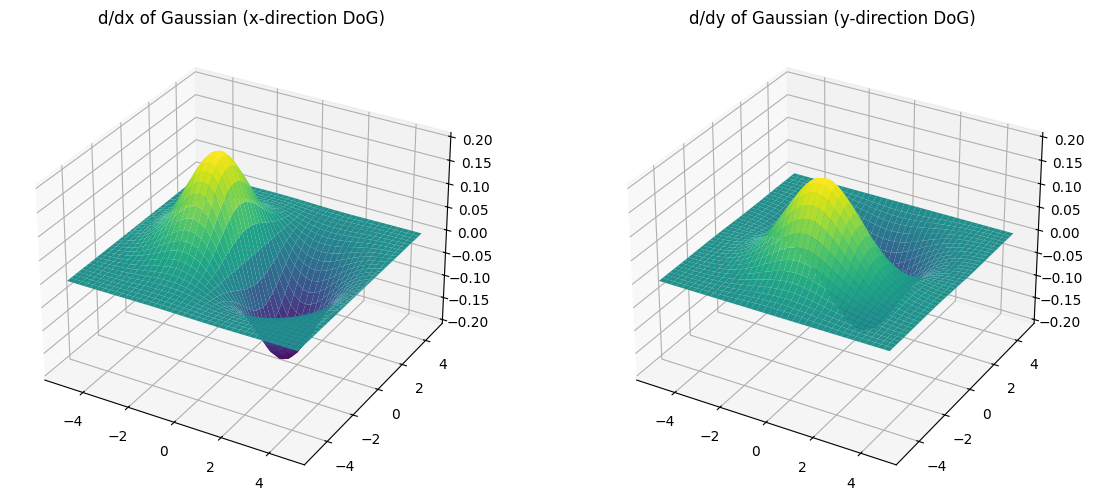

Question from the slides: which one finds horizontal edges vs vertical edges? Which is separable?
-> The bivariate Gaussian is separable (product of 2 univariate Gaussians), and since taking a derivative
   in x (or y) commutes with the separable Gaussian smoothing in y (or x), the derivative-of-Gaussian is
   ALSO separable: apply 1D Gaussian along one axis, 1D derivative along the other.


In [9]:
x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(x, y)
sigma = 1.5
Z = np.exp(-(X**2 + Y**2) / (2*sigma**2))

kernel_cd = np.array([[-1, 0, 1]], dtype=np.float64)
Zx = cv2.filter2D(Z, cv2.CV_64F, kernel_cd)       # d/dx of the gaussian
Zy = cv2.filter2D(Z, cv2.CV_64F, kernel_cd.T)     # d/dy of the gaussian

fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(X, Y, Zx, cmap='viridis'); ax1.set_title('d/dx of Gaussian (x-direction DoG)')
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.plot_surface(X, Y, Zy, cmap='viridis'); ax2.set_title('d/dy of Gaussian (y-direction DoG)')
plt.show()

print('Question from the slides: which one finds horizontal edges vs vertical edges? Which is separable?')
print('-> The bivariate Gaussian is separable (product of 2 univariate Gaussians), and since taking a derivative')
print('   in x (or y) commutes with the separable Gaussian smoothing in y (or x), the derivative-of-Gaussian is')
print('   ALSO separable: apply 1D Gaussian along one axis, 1D derivative along the other.')

## 7. The Canny Edge Detector

Four steps:
1. **Filter with derivative of Gaussian** — smooths noise and computes gradient simultaneously.
2. **Gradient magnitude & orientation** — as in Section 3.
3. **Non-maximum suppression (NMS)** — thick gradient "ridges" get thinned to 1-pixel width by checking, at each pixel, whether it's the local maximum *along the gradient direction* (i.e., perpendicular to the edge). This may require interpolating neighboring pixel values since the gradient direction generally doesn't align with the pixel grid.
4. **Hysteresis thresholding** — two thresholds, `high` and `low` (commonly `low ≈ high / 3`). Pixels above `high` start new edge curves ("strong edges"). Pixels above `low` but below `high` only survive if they're **connected** to an already-accepted strong edge — this lets a strong edge "pull along" a weaker, noisier continuation of itself instead of losing it entirely at a hard single threshold.

OpenCV implements the whole pipeline in one call, `cv2.Canny(image, low_threshold, high_threshold)`.

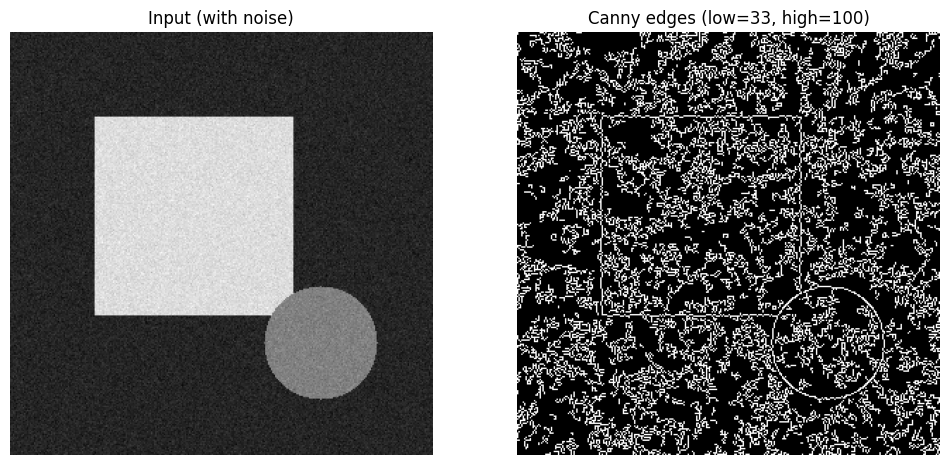

In [10]:
# Try Canny on a real-ish image (a noisy synthetic scene, or load your own from images/ folder)
# If you have a real image, uncomment and point to it:
# real_img = cv2.imread('images/your_image.jpg', cv2.IMREAD_GRAYSCALE)

# Otherwise, build a synthetic scene with soft edges + noise to make Canny's steps visible
canvas = np.ones((300,300), dtype=np.uint8)*40
cv2.rectangle(canvas, (60,60), (200,200), 200, -1)
cv2.circle(canvas, (220,220), 40, 120, -1)
noise = np.random.normal(0, 8, canvas.shape)
real_img = np.clip(canvas.astype(np.float64) + noise, 0, 255).astype(np.uint8)

high_thresh = 100
low_thresh = int(high_thresh / 3)
edges = cv2.Canny(real_img, low_thresh, high_thresh)

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(real_img); ax[0].set_title('Input (with noise)')
ax[1].imshow(edges, cmap='gray'); ax[1].set_title(f'Canny edges (low={low_thresh}, high={high_thresh})')
for a in ax: a.axis('off')
plt.show()

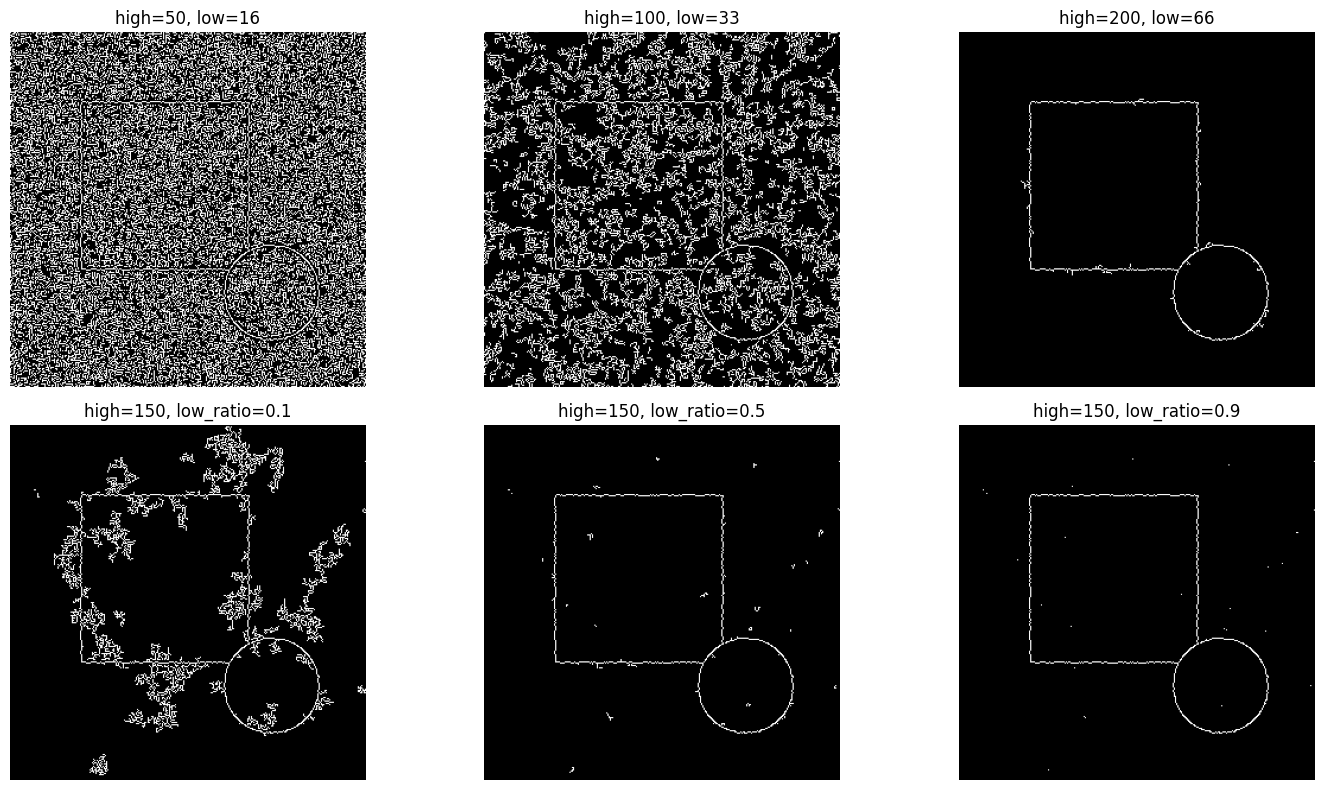

Raising high_threshold -> fewer edges start (less sensitive).
Raising low_threshold toward high -> edge curves stop continuing, they fragment/shorten.


In [11]:
# Interactive-style exploration (matplotlib version of the lecturer's trackbar demo)
fig, axes = plt.subplots(2, 3, figsize=(15,8))
high_values = [50, 100, 200]
for i, high in enumerate(high_values):
    low = int(high/3)
    e = cv2.Canny(real_img, low, high)
    axes[0,i].imshow(e, cmap='gray'); axes[0,i].set_title(f'high={high}, low={low}')
    axes[0,i].axis('off')

# Fix high, vary low/high ratio instead
for i, ratio in enumerate([0.1, 0.5, 0.9]):
    high = 150
    low = int(high*ratio)
    e = cv2.Canny(real_img, low, high)
    axes[1,i].imshow(e, cmap='gray'); axes[1,i].set_title(f'high=150, low_ratio={ratio}')
    axes[1,i].axis('off')
plt.tight_layout(); plt.show()

print('Raising high_threshold -> fewer edges start (less sensitive).')
print('Raising low_threshold toward high -> edge curves stop continuing, they fragment/shorten.')

**Exercise 4**: Add an actual `cv2.createTrackbar` OpenCV window (like your lecturer's code) so you can drag sliders live instead of hardcoding threshold lists. This only works if you run it as a local `.py` script or use `%matplotlib` widgets — trackbars don't render inside a Jupyter cell output directly.

## 8. Corner detection — Harris Corner Detector

**Motivation**: for tasks like panorama stitching, we need distinctive points that are *repeatable* across images (found again despite viewpoint/illumination change), *salient* (locally distinctive), *compact* (far fewer than raw pixels), and *local*.

**Basic idea**: slide a small window over the image. At a true corner, shifting the window in **any** direction causes a **large** change in appearance. At an edge, shifting along the edge direction causes almost no change (only perpendicular shifts change appearance). At a flat region, no shift changes anything.

### The math

Change in appearance for shift $(u,v)$:
$$E(u,v) = \sum_{(x,y)\in W} w(x,y)\,[I(x+u,y+v) - I(x,y)]^2$$

First-order Taylor expansion of $I(x+u,y+v)$ around $(x,y)$ gives a quadratic approximation:

$$E(u,v) \approx \begin{bmatrix}u & v\end{bmatrix} M \begin{bmatrix}u\\v\end{bmatrix}, \qquad
M = \sum_{(x,y)\in W} w(x,y)\begin{bmatrix}I_x^2 & I_xI_y \\ I_xI_y & I_y^2\end{bmatrix}$$

$M$ is the **second moment matrix**. Its eigenvalues $\lambda_1, \lambda_2$ tell you the shape of $E(u,v)$ as an ellipse:
- $(\lambda_{max})^{-1/2}$ = radius along the direction of *fastest* change
- $(\lambda_{min})^{-1/2}$ = radius along the direction of *slowest* change

**Classification**:
| both λ small | one λ >> other | both λ large & similar |
|---|---|---|
| flat region | edge | **corner** |

Computing eigenvalues explicitly is expensive, so Harris & Stephens proposed the cheaper **corner response function**:

$$R = \det(M) - \alpha \cdot \text{trace}(M)^2 = \lambda_1\lambda_2 - \alpha(\lambda_1+\lambda_2)^2, \quad \alpha \in [0.04, 0.06]$$

- $R > 0$ large → corner
- $R < 0$ → edge
- $|R|$ small → flat

$\det(M)$ and $\text{trace}(M)$ are computable directly from the matrix entries ($ad-bc$ and $a+d$) — no eigendecomposition needed. That's the whole point of using $R$ instead of eigenvalues directly.

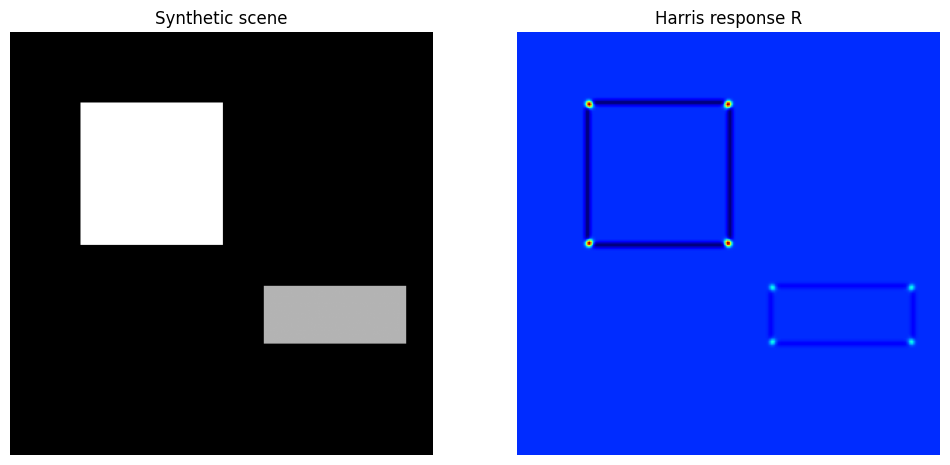

In [12]:
# Build a synthetic scene with clear corners, edges, and flat regions
scene = np.zeros((300,300), dtype=np.uint8)
cv2.rectangle(scene, (50,50), (150,150), 255, -1)     # a square -> 4 sharp corners
cv2.rectangle(scene, (180,180), (280,220), 180, -1)   # a rectangle -> edges + corners
scene_f = scene.astype(np.float32)

# Step 1: derivatives
Ix = cv2.Sobel(scene_f, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(scene_f, cv2.CV_64F, 0, 1, ksize=3)

Ixx = Ix*Ix
Iyy = Iy*Iy
Ixy = Ix*Iy

# Step 2: sum within a Gaussian window (this IS the second moment matrix M, per-pixel)
sigma = 2
Sxx = cv2.GaussianBlur(Ixx, (0,0), sigma)
Syy = cv2.GaussianBlur(Iyy, (0,0), sigma)
Sxy = cv2.GaussianBlur(Ixy, (0,0), sigma)

# Step 3: corner response R = det(M) - alpha*trace(M)^2
alpha = 0.05
detM = Sxx*Syy - Sxy*Sxy
traceM = Sxx + Syy
R = detM - alpha*(traceM**2)

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(scene, cmap='gray'); ax[0].set_title('Synthetic scene')
ax[1].imshow(R, cmap='jet'); ax[1].set_title('Harris response R')
for a in ax: a.axis('off')
plt.show()

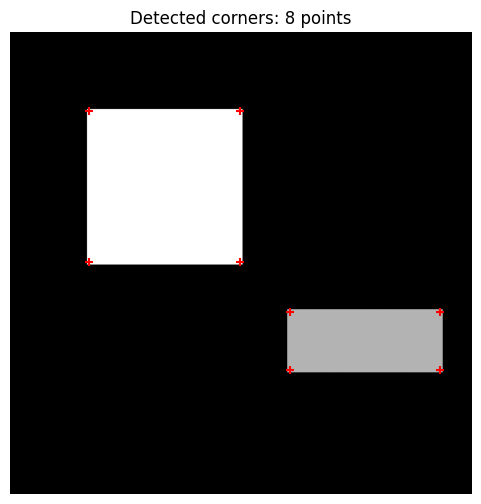

In [13]:
# Step 4 & 5: threshold R, then non-max suppression to get final corner points
R_norm = cv2.normalize(R, None, 0, 1, cv2.NORM_MINMAX)
threshold = 0.3

corner_mask = (R_norm > threshold)
# local maxima via dilation trick: a pixel survives only if it equals the local max in its neighborhood
local_max = (R == ndimage.maximum_filter(R, size=7))
corners = np.argwhere(corner_mask & local_max)

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(scene, cmap='gray')
ax.scatter(corners[:,1], corners[:,0], c='red', s=30, marker='+')
ax.set_title(f'Detected corners: {len(corners)} points')
ax.axis('off')
plt.show()

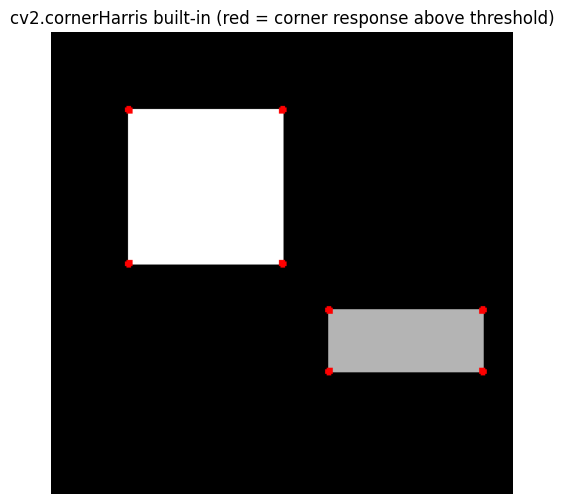

In [14]:
# Sanity check / comparison against OpenCV's built-in Harris implementation
harris_response = cv2.cornerHarris(scene_f, blockSize=5, ksize=3, k=0.05)
harris_norm = cv2.normalize(harris_response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

vis = cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)
vis[harris_response > 0.01*harris_response.max()] = [0,0,255]

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("cv2.cornerHarris built-in (red = corner response above threshold)")
plt.axis('off')
plt.show()

### Invariance vs. covariance — important distinction, often confused

- **Invariant**: the output doesn't change at all under the transformation (e.g., a descriptor value should be the *same number* before and after rotation).
- **Covariant**: the output changes *in a corresponding way* — if the image is transformed, the detected feature locations move along with it, so you can still find "the same" point in both images.

Harris corner **locations** are:
- **Covariant to translation** ✔️ (corner just moves with the image)
- **Covariant to rotation** ✔️ (the second-moment ellipse rotates, but eigenvalues — hence corner-ness — stay the same)
- **Partially invariant to affine intensity change** $I \to aI+b$: invariant to the additive shift $b$ (because only derivatives are used, and derivatives kill constants), but the multiplicative gain $a$ changes the *magnitude* of $R$, so if you're using a fixed threshold, corners can appear/disappear as $a$ changes. So: invariant to bias, sensitive to gain (only "partially" invariant).
- **NOT covariant to scaling** ❌ — this is the big one. If you zoom into a corner far enough, the window that used to see "two edges meeting" now just sees "one straight edge" locally, so it gets misclassified. This is exactly the motivation for the next section: blob detection with automatic scale selection.

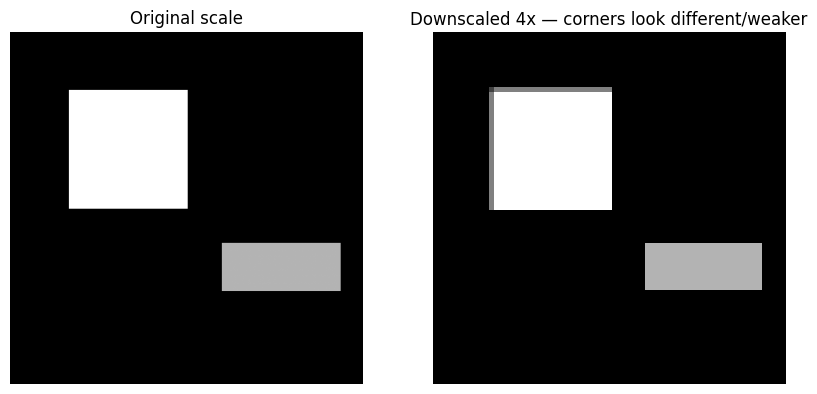

In [15]:
# Demonstrate the scale problem directly: scale the image down and see corner count/location degrade
small_scene = cv2.resize(scene, (75,75), interpolation=cv2.INTER_LINEAR)
small_f = small_scene.astype(np.float32)
harris_small = cv2.cornerHarris(small_f, blockSize=5, ksize=3, k=0.05)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(scene, cmap='gray'); ax[0].set_title('Original scale')
ax[1].imshow(small_scene, cmap='gray'); ax[1].set_title('Downscaled 4x — corners look different/weaker')
for a in ax: a.axis('off')
plt.show()

## 9. Blob Detection

**Goal**: detect "blob-like" structures (roughly circular regions distinct from their surroundings) *at their characteristic scale* — i.e., find both **where** a blob is and **how big** it is, in a way that's covariant to scaling (unlike Harris corners).

### From edges to blobs

- An **edge** looks like a single ripple in the intensity profile → its derivative has one extremum, and its 2nd derivative has one zero-crossing.
- A **blob** looks like the *superposition of two ripples* (two nearby edges, e.g. the two sides of a circle) → the 2nd derivative response is **maximal at the blob's center**, provided the scale of the filter matches the scale of the blob.

### Laplacian of Gaussian (LoG)

$$\nabla^2 g = \frac{\partial^2 g}{\partial x^2} + \frac{\partial^2 g}{\partial y^2}$$

This is circularly symmetric — good, because blobs don't have a preferred orientation like edges do.

### The scale-normalization subtlety (important, often missed)

The *raw* response of a Gaussian derivative filter to a fixed edge/blob **decays** as $\sigma$ increases (the filter energy spreads out, response per-pixel drops), even at the "correct" matching scale. If you don't correct for this, larger blobs will always look artificially "weaker" than small ones, which breaks scale comparison. The fix: multiply by $\sigma$ for a first derivative, or $\sigma^2$ for the Laplacian (second derivative):

$$\nabla^2_{norm} g = \sigma^2 \left(\frac{\partial^2 g}{\partial x^2} + \frac{\partial^2 g}{\partial y^2}\right)$$

### Matching a circle of radius r

For a **binary circle of radius $r$**, the scale-normalized LoG achieves its maximum response when:

$$\sigma = r/\sqrt{2}$$

This gives you a direct way to *read off* blob size from the scale at which the response peaks — this peak scale is called the **characteristic scale** of the blob.

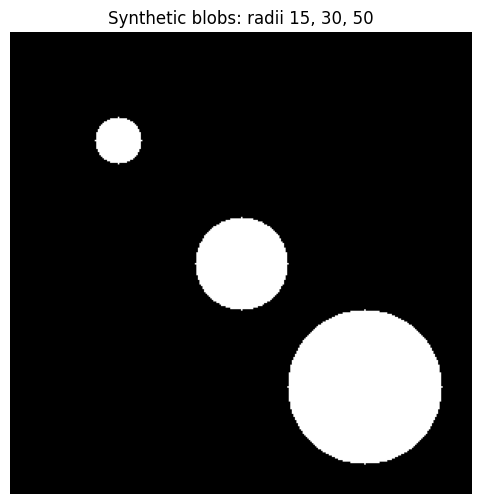

In [16]:
# Build a synthetic image with blobs of different sizes to demonstrate scale selection
blob_img = np.zeros((300,300), dtype=np.float64)
centers_radii = [(70,70,15), (150,150,30), (230,230,50)]
for (cy,cx,r) in centers_radii:
    yy,xx = np.ogrid[:300,:300]
    mask = (yy-cy)**2 + (xx-cx)**2 <= r**2
    blob_img[mask] = 255

plt.imshow(blob_img)
plt.title('Synthetic blobs: radii 15, 30, 50')
plt.axis('off')
plt.show()

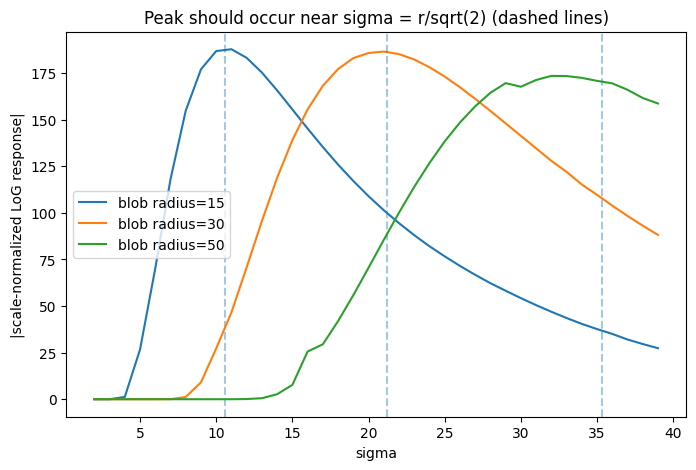

In [17]:
# Scale-space: convolve with scale-normalized LoG at many sigmas, find max response at each blob center
sigmas = np.arange(2, 40, 1)
responses = []

for sigma in sigmas:
    ksize = int(6*sigma+1) | 1
    log_kernel = cv2.getGaussianKernel(ksize, sigma)
    log_kernel_2d = log_kernel @ log_kernel.T
    # Laplacian via cv2.Laplacian applied AFTER gaussian smoothing (equivalent to LoG for this purpose)
    smoothed = cv2.filter2D(blob_img, cv2.CV_64F, log_kernel_2d)
    lap = cv2.Laplacian(smoothed, cv2.CV_64F)
    lap_norm = (sigma**2) * lap   # <-- the scale normalization step
    responses.append(lap_norm)

responses = np.array(responses)  # shape (n_sigma, H, W)

# Read off response at each blob's center across scale
fig, ax = plt.subplots(figsize=(8,5))
for (cy,cx,r) in centers_radii:
    profile = np.abs(responses[:, cy, cx])
    ax.plot(sigmas, profile, label=f'blob radius={r}')
    predicted_sigma = r/np.sqrt(2)
    ax.axvline(predicted_sigma, linestyle='--', alpha=0.4)
ax.set_xlabel('sigma')
ax.set_ylabel('|scale-normalized LoG response|')
ax.set_title('Peak should occur near sigma = r/sqrt(2) (dashed lines)')
ax.legend()
plt.show()

Check: does the peak of each curve line up with its dashed line ($\sigma = r/\sqrt2$)? If there's a small offset, that's expected — it comes from discretization (grid sampling) and the "binary circle" assumption not perfectly matching Gaussian-kernel discretization. The **trend** (bigger blob → peak at bigger sigma) is the important qualitative result.

### Efficient implementation: Difference of Gaussians (DoG)

Computing LoG (second derivatives) at many scales is expensive. Lowe (SIFT) showed the Laplacian can be closely **approximated** by a difference of two Gaussians at nearby scales:

$$\text{DoG} = G(x,y,k\sigma) - G(x,y,\sigma) \approx (k-1)\sigma^2 \nabla^2 g$$

This only needs two Gaussian blurs and a subtraction — no explicit second-derivative computation — which is why SIFT uses DoG pyramids instead of LoG directly.

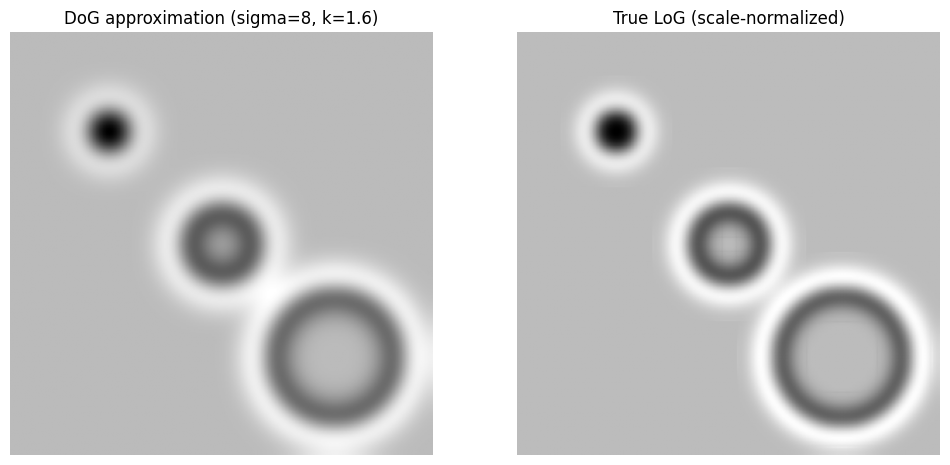

Shapes should look very similar -- DoG is a cheap stand-in for LoG.


In [18]:
# DoG approximation of LoG, compared directly
sigma = 8
k = 1.6  # common SIFT choice
ksize1 = int(6*sigma+1)|1
ksize2 = int(6*sigma*k+1)|1

g1 = cv2.GaussianBlur(blob_img, (ksize1,ksize1), sigma)
g2 = cv2.GaussianBlur(blob_img, (ksize2,ksize2), sigma*k)
dog = g2 - g1

# compare against true LoG at same sigma
gk = cv2.getGaussianKernel(ksize1, sigma)
smoothed_true = cv2.filter2D(blob_img, cv2.CV_64F, gk @ gk.T)
log_true = (sigma**2) * cv2.Laplacian(smoothed_true, cv2.CV_64F)

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(dog, cmap='gray'); ax[0].set_title(f'DoG approximation (sigma={sigma}, k={k})')
ax[1].imshow(log_true, cmap='gray'); ax[1].set_title('True LoG (scale-normalized)')
for a in ax: a.axis('off')
plt.show()
print('Shapes should look very similar -- DoG is a cheap stand-in for LoG.')

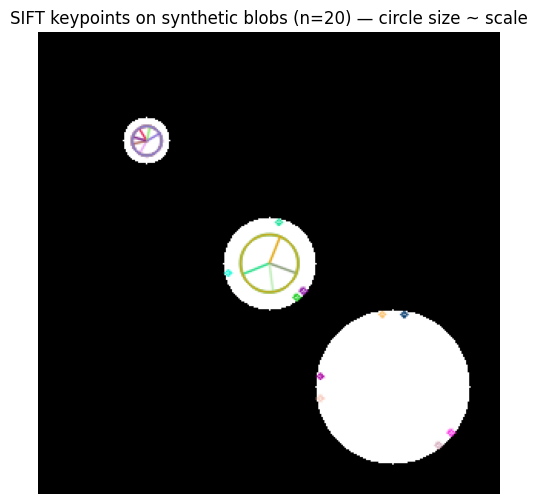

pos=(70,70), size(scale)=19.2, angle=119.7 deg
pos=(70,70), size(scale)=19.2, angle=167.6 deg
pos=(70,70), size(scale)=19.2, angle=195.7 deg
pos=(70,70), size(scale)=19.2, angle=238.1 deg
pos=(70,70), size(scale)=19.2, angle=282.4 deg
pos=(70,70), size(scale)=19.2, angle=330.3 deg
pos=(123,156), size(scale)=3.9, angle=349.8 deg
pos=(150,150), size(scale)=37.4, angle=20.0 deg
pos=(150,150), size(scale)=37.4, angle=82.5 deg
pos=(150,150), size(scale)=37.4, angle=157.9 deg
pos=(150,150), size(scale)=37.4, angle=292.1 deg
pos=(156,123), size(scale)=3.9, angle=100.2 deg
pos=(168,172), size(scale)=4.3, angle=232.2 deg
pos=(172,168), size(scale)=4.3, angle=218.0 deg
pos=(183,223), size(scale)=3.6, angle=6.3 deg
pos=(183,237), size(scale)=3.8, angle=354.6 deg
pos=(223,183), size(scale)=3.6, angle=83.7 deg
pos=(237,183), size(scale)=3.8, angle=95.4 deg
pos=(260,268), size(scale)=4.2, angle=231.7 deg
pos=(268,260), size(scale)=4.2, angle=218.3 deg


In [19]:
# Using OpenCV's built-in blob / SIFT detectors to tie it all together
sift = cv2.SIFT_create()
blob_img_u8 = blob_img.astype(np.uint8)
keypoints = sift.detect(blob_img_u8, None)

vis = cv2.drawKeypoints(blob_img_u8, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(vis)
plt.title(f'SIFT keypoints on synthetic blobs (n={len(keypoints)}) — circle size ~ scale')
plt.axis('off')
plt.show()

for kp in keypoints:
    print(f'pos=({kp.pt[0]:.0f},{kp.pt[1]:.0f}), size(scale)={kp.size:.1f}, angle={kp.angle:.1f} deg')

Notice each detected SIFT keypoint carries **position + scale (size) + orientation (angle)**. That's exactly the "detection is covariant" idea from the slides: if you rotate/scale the image, SIFT keypoints move/scale/rotate correspondingly, so you can match "the same" physical point across two different views of it.

## 10. SIFT: detection vs. description (conceptual summary)

- **Detection** (finding *where* and *at what scale*) must be **covariant**: `features(transform(image)) = transform(features(image))`.
- **Description** (encoding *what the patch looks like*, as a fixed-length vector) must be **invariant**: `features(transform(image)) = features(image)` — the descriptor vector itself should be (nearly) unchanged regardless of viewpoint, so you can compare descriptors across images with simple distance metrics.

To make the description step rotation-invariant, SIFT:
1. Builds a histogram of local gradient orientations in the patch around the keypoint.
2. Picks the peak of the (smoothed) histogram as the patch's **canonical orientation**.
3. Rotates the patch to align with that canonical orientation before computing the final descriptor.

The final SIFT descriptor is a 4×4 grid of 8-bin orientation histograms = 128 dimensions total.

## Summary / self-test

Before moving on, you should be able to answer without looking back:

1. Why must derivative-filter coefficients sum to zero, but smoothing-filter coefficients sum to one?
2. Why do we smooth before differentiating, and why is doing so mathematically equivalent (via the derivative theorem of convolution) to convolving with a single derivative-of-Gaussian kernel?
3. What do the two eigenvalues of the second moment matrix $M$ tell you about a Harris corner vs. an edge vs. a flat region?
4. Why is the Harris response $R = \det(M) - \alpha\,\text{trace}(M)^2$ preferred over computing eigenvalues directly?
5. Is Harris corner detection invariant, covariant, or neither, to: (a) translation (b) rotation (c) scaling (d) affine intensity change $I \to aI+b$?
6. Why does the raw LoG response need scale normalization ($\sigma^2$ factor) before comparing responses across scales?
7. At what $\sigma$ does a scale-normalized LoG give its peak response to a binary circle of radius $r$?
8. What's the practical reason SIFT uses DoG instead of computing LoG directly?
9. What's the difference between detection covariance and description invariance?